In [1]:
pip install numpy scipy matplotlib ipython scikit-learn pandas mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 9.0 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mglearn
import scipy as sp
import sklearn
import IPython

# Supervised Learning

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive 
...
Target names: ['setosa' 'versicolor' 'virginica']
Feature names: 
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Shape of data: (150, 4)
First five columns of data:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
Shape of target: (150,)
Target:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
X_train shape: (112, 4)
y_train shape: (112,)
X_test shape:

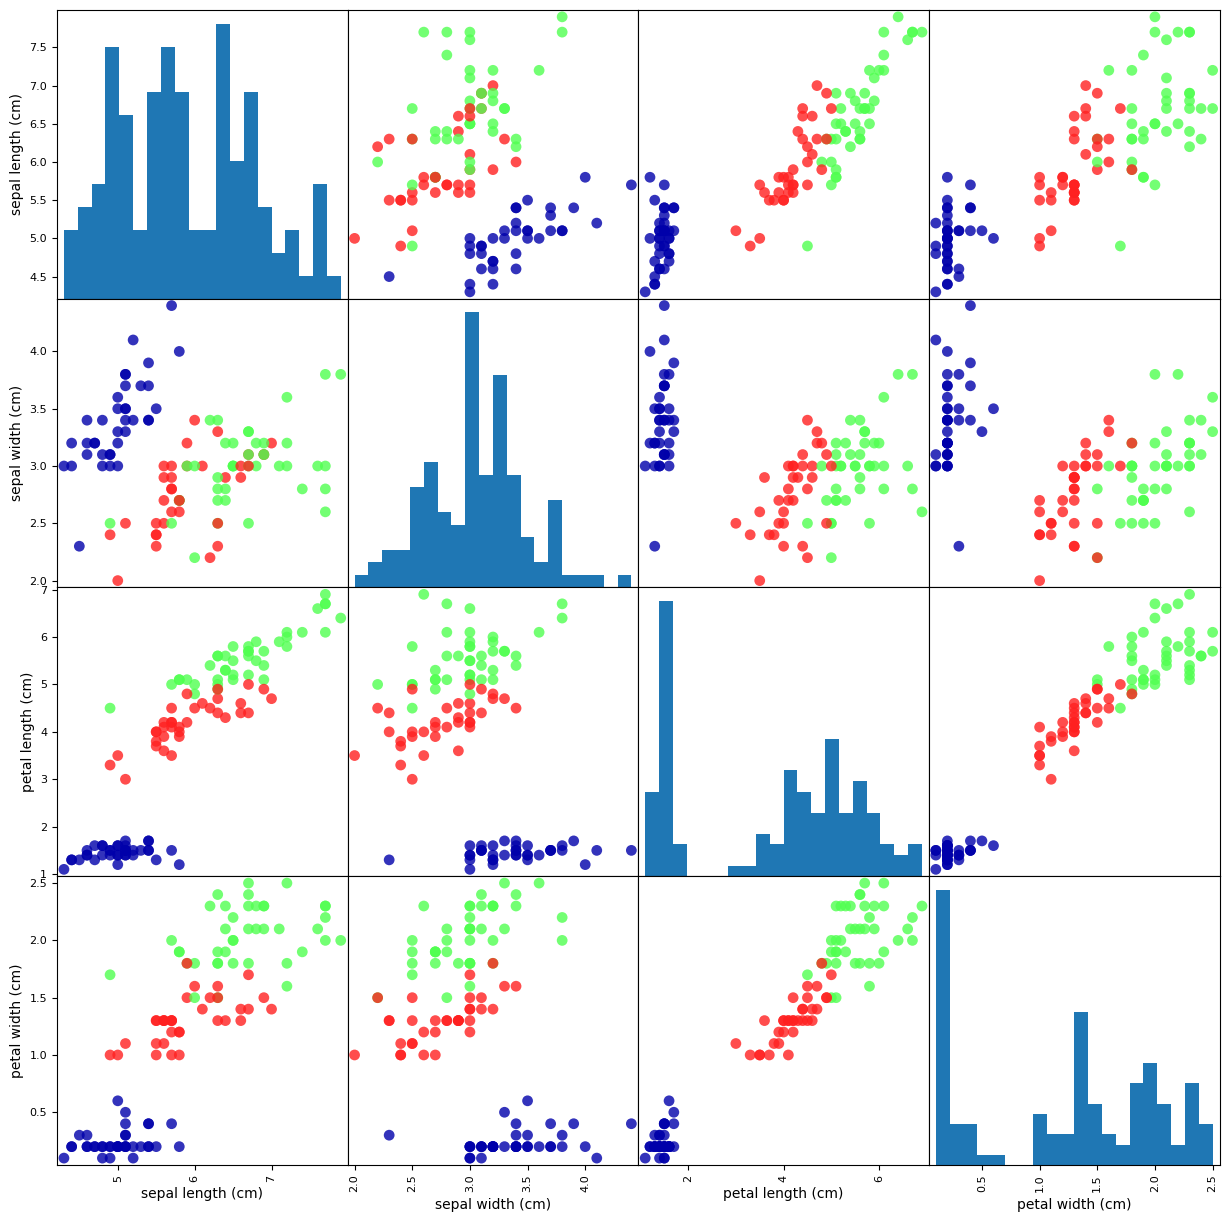

In [3]:
#Classifying Iris species
from sklearn.datasets import load_iris
iris_dataset=load_iris()
print(format(iris_dataset.keys()))

print(iris_dataset['DESCR'][:193]+"\n...")  #Short description of dataset

print("Target names: {}".format(iris_dataset['target_names'])) #List of flower species

print("Feature names: \n{}".format(iris_dataset['feature_names'])) #Description of each feature

print("Shape of data: {}".format(iris_dataset['data'].shape)) #Shape of data

print("First five columns of data:\n{}".format(iris_dataset['data'][:5]))

print("Shape of target: {}".format(iris_dataset['target'].shape)) #Shape of target

print("Target:\n{}".format(iris_dataset['target'])) #Target description from 0 to 2, 0 means setosa, 1 means versicolor, and 2 means virginica.

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(iris_dataset['data'], iris_dataset['target'], random_state=0)

print("X_train shape:",X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

#pair-plot to visualize the data
from pandas.plotting import scatter_matrix
iris_dataframe=pd.DataFrame(X_train, columns=iris_dataset.feature_names)
grr=scatter_matrix(iris_dataframe, c=y_train, figsize=(15,15), marker='o', hist_kwds={'bins':20},s=60,alpha=.8,cmap=mglearn.cm3)

#Training K nearest neighbour
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

#Making predictions
X_new=np.array([[3,3.9,1.4,0.2]])
print("X_new.shape", X_new.shape)
prediction=knn.predict(X_new)
print("Prediction", prediction)
print("Predicted name", iris_dataset['target_names'][prediction])

#Evaluating model
y_pred=knn.predict(X_test)
print("Test set predictions:\n",y_pred)
print("Test set score: {:.2f}",np.mean(y_pred==y_test))
print("Test set score: {:.2f}",knn.score(X_test,y_test))

In [6]:
#loading pre built cancer dataset
from sklearn.datasets import load_breast_cancer
cancer=load_breast_cancer()
print("Cancer.keys:\n",cancer.keys())
print("Cancer data shape:", cancer.data.shape)
print("Sample counts per class:", {n: v for n, v in zip(cancer.target_names, np.bincount(cancer.target))})
print("Feature names:", cancer.feature_names)

Cancer.keys:
 dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
Cancer data shape: (569, 30)
Sample counts per class: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [10]:
#Load boston housing data
from sklearn.datasets import fetch_california_housing
california=fetch_california_housing()
print("California keys:", california.keys())
print("Data shape:", boston.data.shape)
# print("California description:", california.DESCR)


California keys: dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])
Data shape: (20640, 8)
California description: .. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for Californ

### K nearest neighbors

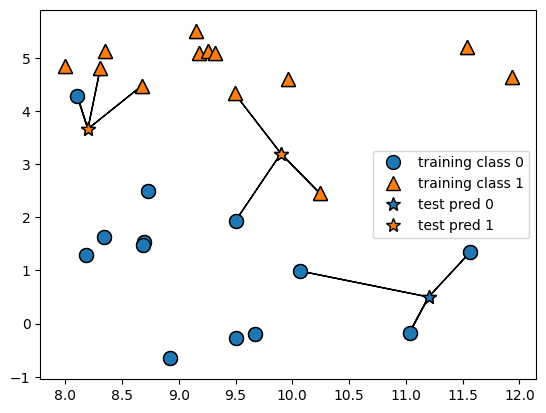

In [12]:
mglearn.plots.plot_knn_classification(n_neighbors=1)
mglearn.plots.plot_knn_classification(n_neighbors=3)

In [7]:
#K_Neighbors_Classifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier
cancer= load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer['data'],cancer['target'], random_state=0)
clf=KNeighborsClassifier(n_neighbors=3)
clf.fit(X_train, y_train) #Fit the classifier using training set
print("Target names:", cancer.target_names)
print("Test set predictions:", clf.predict(X_test))
print("Test accuracy:", clf.score(X_test, y_test))

Target names: ['malignant' 'benign']
Test set predictions: [0 1 1 0 1 1 1 1 1 1 0 1 1 0 0 0 1 0 0 0 0 0 1 1 0 1 1 1 1 0 1 0 1 0 1 0 1
 0 1 0 0 1 0 1 0 0 1 1 1 0 0 1 0 1 1 1 1 1 1 0 0 0 1 1 0 1 0 0 0 1 1 0 1 1
 0 1 1 1 1 1 0 0 0 1 0 1 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 1 1 0 1 0 0 0 0 1
 0 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 0 0 1 1 1 0]
Test accuracy: 0.9230769230769231


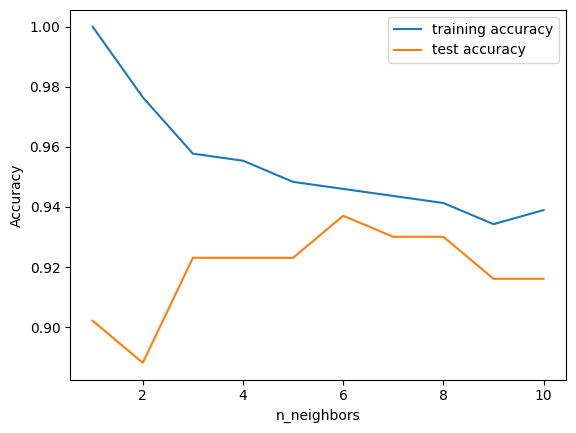

In [8]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
cancer.data, cancer.target, stratify=cancer.target, random_state=66)
training_accuracy = []
test_accuracy = []
# try n_neighbors from 1 to 10
neighbors_settings = range(1, 11)
for n_neighbors in neighbors_settings:
    # build the model
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)
    clf.fit(X_train, y_train)
    # record training set accuracy
    training_accuracy.append(clf.score(X_train, y_train))
    # record generalization accuracy
    test_accuracy.append(clf.score(X_test, y_test))
plt.plot(neighbors_settings, training_accuracy, label="training accuracy")
plt.plot(neighbors_settings, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

In [13]:
#K_Neighbors_Regressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
california=fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(california['data'], california['target'], random_state=0)
reg=KNeighborsRegressor(n_neighbors=3).fit(X_train, y_train)
print("Data keys: ", california.keys())
print("Target values: ", california.target)
print("Target name: ", california.target_names)
print("Test set predictions:", reg.predict(X_test))
print("Test accuracy/ R2 score: ", reg.score(X_test, y_test))

Data keys:  dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])
Target values:  [4.526 3.585 3.521 ... 0.923 0.847 0.894]
Target name:  ['MedHouseVal']
Test set predictions: [1.82266667 2.228      3.08833333 ... 1.49266667 2.653      2.96733333]
Test accuracy/ R2 score:  0.11587927803940512


### Linear models for regression

California data keys:  dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])
California column names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
California housing target col:  ['MedHouseVal']
Value of w/lr.coef_:  [ 4.39091042e-01  9.59864665e-03 -1.03311173e-01  6.16730152e-01
 -7.63275197e-06 -4.48838256e-03 -4.17353284e-01 -4.30614462e-01]
Value of b/lr.intercept:  -36.609593778714334
Train data accuracy:  0.6109633715458153
Test data accuracy/R2 score:  0.5911695436410476
Test data prediction:  [2.27826207 2.79606672 1.90887117 ... 2.15678592 3.03507742 2.89088222]
---------------Plots-----------------
Train R2: 0.6109633715458153
Test R2: 0.5911695436410476


/tmp/ipykernel_54/433090816.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


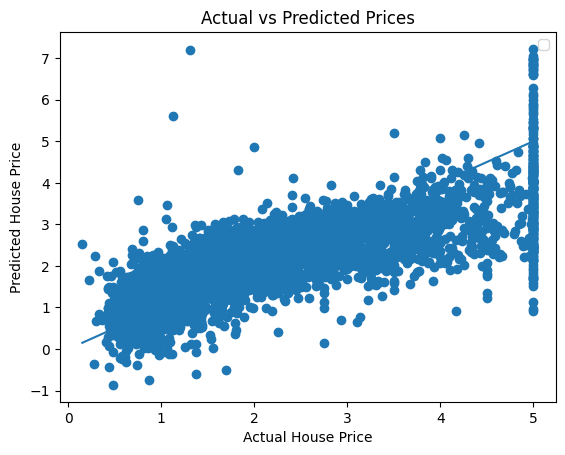

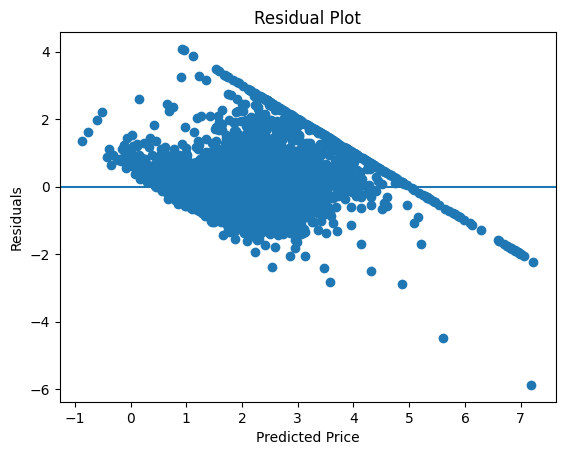

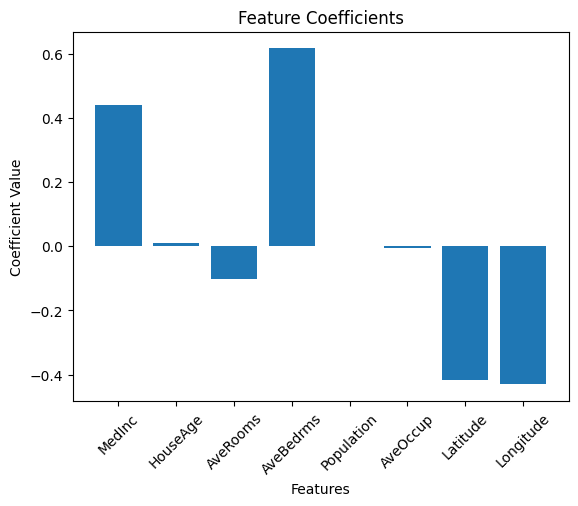

In [47]:
#Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# X,y=make_regression(n_samples=10000, n_features=20, noise=10, random_state=42)
california=fetch_california_housing()
print("California data keys: ", california.keys())
print("California column names:", california.feature_names)
print("California housing target col: ",california.target_names)
# X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=0)
X_train, X_test, y_train, y_test = train_test_split(california['data'], california['target'], random_state=0)
lr=LinearRegression().fit(X_train, y_train)
print("Value of w/lr.coef_: ", lr.coef_) #Slope parameters (w) also called as weights or coefficeint are stored as coef_
print("Value of b/lr.intercept: ", lr.intercept_) #Value of b which is offset or intercept
print("Train data accuracy: ", lr.score(X_train, y_train))
print("Test data accuracy/R2 score: ", lr.score(X_test, y_test))
print("Test data prediction: ", lr.predict(X_test))

print("---------------Plots-----------------")
import matplotlib.pyplot as plt
import pandas as pd

# Predictions
y_pred = lr.predict(X_test)

print("Train R2:", lr.score(X_train, y_train))
print("Test R2:", lr.score(X_test, y_test))

# ===============================
# 1️ Actual vs Predicted Plot
# ===============================

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.legend()
plt.title("Actual vs Predicted Prices")

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.show()


# ===============================
# 2 Residual Plot
# ===============================

residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


# ===============================
# 3️ Coefficient Plot
# ===============================

plt.figure()
plt.bar(california.feature_names, lr.coef_)
plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.title("Feature Coefficients")
plt.show()

Training score:  0.6076805976406299
Test score:  0.6014186487285864


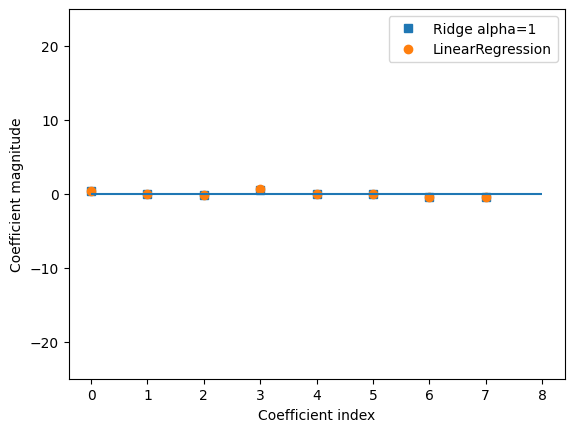

In [52]:
#Ridge regression
from sklearn.linear_model import Ridge
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
california=fetch_california_housing()

X_train, X_test, y_train, y_test = train_test_split(california['data'], california['target'], random_state=50)
ri=Ridge().fit(X_train, y_train)
# ri=Ridge(alpha=10).fit(X_train, y_train) #by default, alpha is 1
print("Training score: ", ri.score(X_train, y_train))
print("Test score: ", ri.score(X_test, y_test))

plt.plot(ri.coef_, 's', label="Ridge alpha=1")
# plt.plot(ridge10.coef_, '^', label="Ridge alpha=10")
# plt.plot(ridge01.coef_, 'v', label="Ridge alpha=0.1")
plt.plot(lr.coef_, 'o', label="LinearRegression")
plt.xlabel("Coefficient index")
plt.ylabel("Coefficient magnitude")
plt.hlines(0, 0, len(lr.coef_))
plt.ylim(-25,25)
plt.legend()

Shape of data:  (20640, 8)
With default alpha 1
Training set score:  0.2923162004273603
Test set score:  0.28490402733386166
Number of features used:  3
----------------------------------------
With alpha 0.01 and max_iter 100000
Training set score:  0.6072415448334423
Test set score:  0.5855078217958598
Number of features used:  8


Text(0, 0.5, 'Coefficient magnitude')

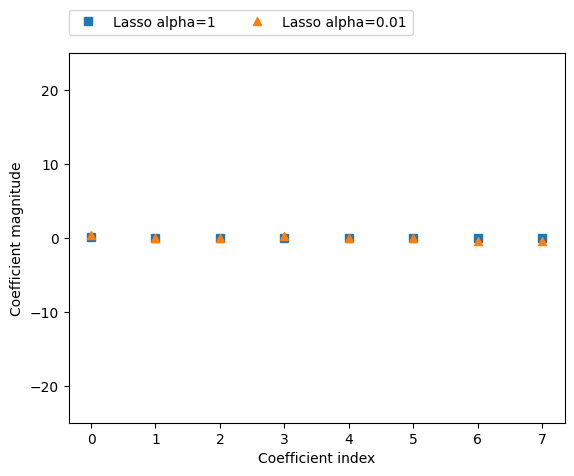

In [11]:
#Lasso regression
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
import numpy as np

california=fetch_california_housing()

X_train, X_test, y_train, y_test = train_test_split(california['data'], california['target'], random_state=0)
La_1=Lasso().fit(X_train, y_train)
La_2=Lasso(alpha=0.01, max_iter=100000).fit(X_train, y_train)
print("Shape of data: ", california['data'].shape)
print("With default alpha 1")
print("Training set score: ", La_1.score(X_train, y_train))
print("Test set score: ", La_1.score(X_test, y_test))
print("Number of features used: ", np.sum(La_1.coef_!=0))
print("----------------------------------------")
print("With alpha 0.01 and max_iter 100000")
print("Training set score: ",La_2.score(X_train, y_train))
print("Test set score: ", La_2.score(X_test, y_test))
print("Number of features used: ",np.sum(La_2.coef_!=0))

plt.plot(La_1.coef_, 's', label="Lasso alpha=1")
plt.plot(La_2.coef_, '^', label="Lasso alpha=0.01")
plt.legend(ncol=2, loc=(0, 1.05))
plt.ylim(-25, 25)
plt.xlabel("Coefficient index")
plt.ylabel("Coefficient magnitude")

### Linear models for classification

C= 0.01
Training accuracy:  0.9530516431924883
Test accuracy:  0.9440559440559441
Target names:  ['malignant' 'benign']
Test prediction:  [0 1 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 0 0 0 0 0 1 1 0 1 1 0 1 0 1 0 1 0 1 0 1
 0 1 0 0 1 0 1 0 0 1 1 1 0 0 0 0 1 1 1 1 1 1 0 0 0 1 1 0 1 0 0 0 1 0 0 1 1
 0 1 1 1 1 1 0 0 0 1 0 1 1 1 0 0 1 0 0 0 1 1 0 1 1 1 1 1 1 1 0 1 0 1 0 0 1
 0 0 1 1 1 1 1 1 1 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 0 0 0 1 1 1 0]
C= 0.10
Training accuracy:  0.9577464788732394
Test accuracy:  0.9440559440559441
Target names:  ['malignant' 'benign']
Test prediction:  [0 1 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 0 0 0 0 0 1 1 0 1 1 0 1 0 1 0 1 0 1 0 1
 0 1 0 0 1 0 1 0 0 1 1 1 0 0 0 0 1 1 1 1 1 1 0 0 0 1 1 0 1 0 0 0 1 0 0 1 1
 0 1 1 1 1 1 0 0 0 1 0 1 1 1 0 0 1 0 0 0 1 1 0 1 1 1 1 1 1 1 0 1 0 1 0 0 1
 0 0 1 1 1 1 1 1 1 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 0 0 0 1 1 1 0]
C= 1.00
Training accuracy:  0.960093896713615
Test accuracy:  0.951048951048951
Target names:  ['malignant' 'benign']
Test prediction:  [0 1 1

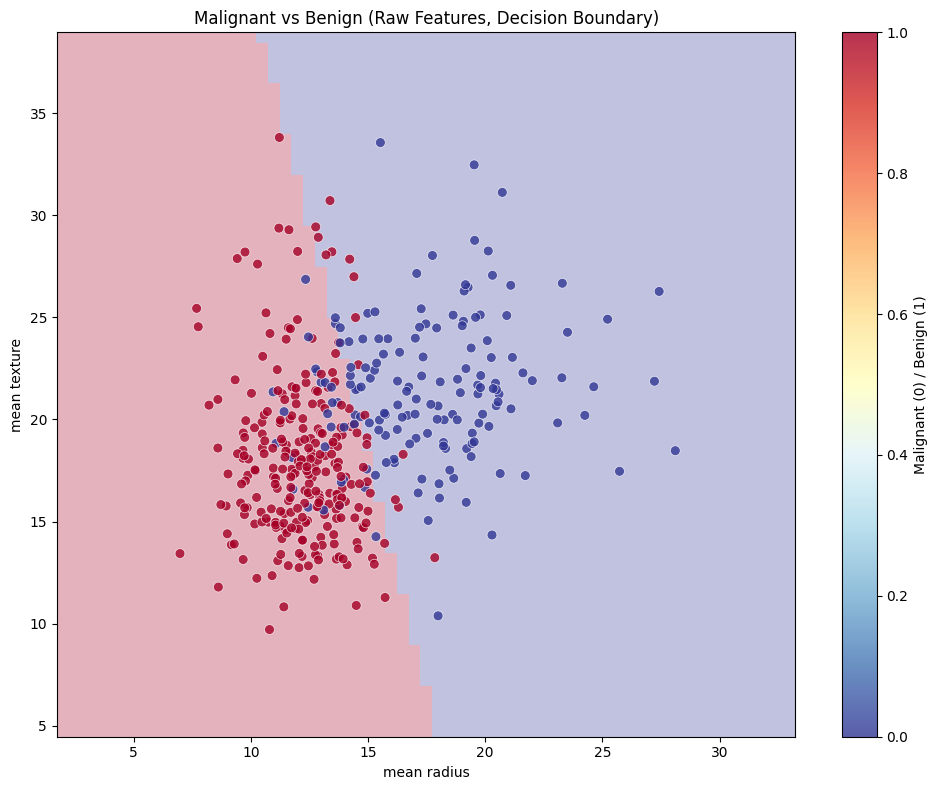

In [9]:
#Logistic Regression - Binomial
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

cancer=load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer['data'], cancer['target'], random_state=0)

C_values=[0.01, 0.1, 1.0, 10.0, 100.0]
for C in C_values:
    clr_B=LogisticRegression(C=C,max_iter=100000).fit(X_train, y_train)
    print(f'C={C:5.2f}')
    print("Training accuracy: ", clr_B.score(X_train, y_train))
    print("Test accuracy: ", clr_B.score(X_test, y_test))
    print("Target names: ", cancer.target_names)
    print("Test prediction: ", clr_B.predict(X_test))
#---------------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np

# cancer = load_breast_cancer()
# X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=0)

# Raw features 0 & 1 (no scaling)
feat1, feat2 = 0, 1
X_train_2d = X_train[:, [feat1, feat2]]

logreg = LogisticRegression(max_iter=100000).fit(X_train_2d, y_train)

# Meshgrid (coarser step for raw scale)
x_min, x_max = X_train_2d[:, 0].min() - 5, X_train_2d[:, 0].max() + 5
y_min, y_max = X_train_2d[:, 1].min() - 5, X_train_2d[:, 1].max() + 5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.5), np.arange(y_min, y_max, 0.5))
Z = logreg.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.pcolormesh(xx, yy, Z, cmap='RdYlBu_r', alpha=0.3)
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap='RdYlBu_r', 
            alpha=0.8, s=50, edgecolors='w', linewidth=0.5)
plt.xlabel(cancer.feature_names[feat1])
plt.ylabel(cancer.feature_names[feat2])
plt.title('Malignant vs Benign (Raw Features, Decision Boundary)')
plt.colorbar(label='Malignant (0) / Benign (1)')
plt.tight_layout()
plt.show()


Training accuracy:  0.9821428571428571
Test accuracy:  0.9736842105263158
Target names:  ['setosa' 'versicolor' 'virginica']
Test prediction:  [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 2]


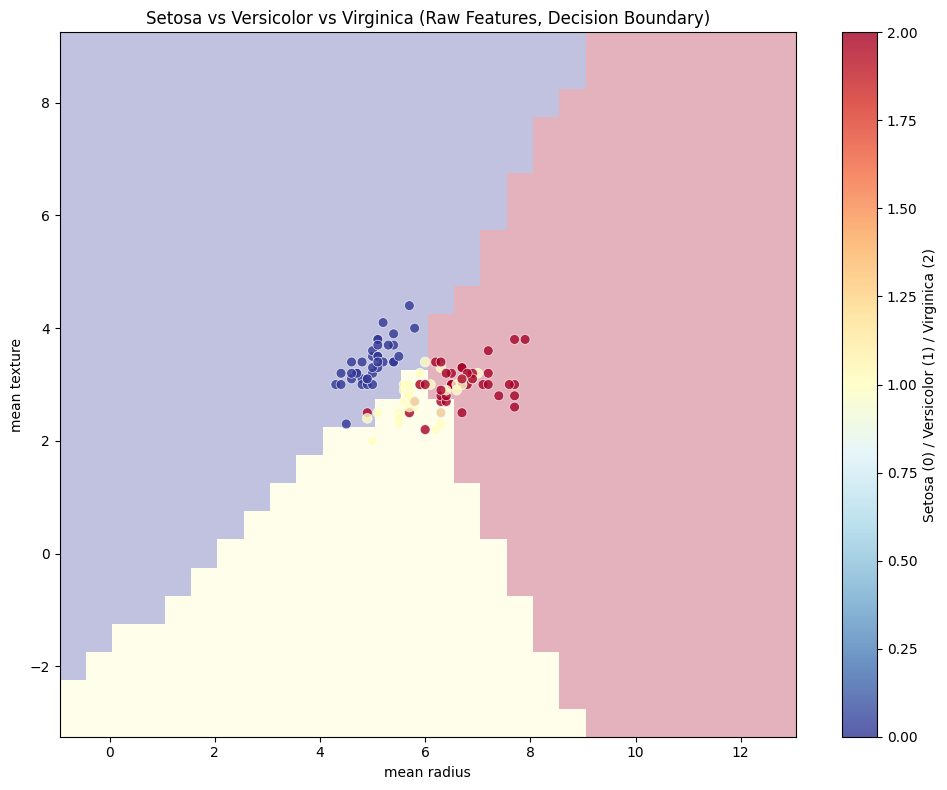

In [7]:
#Logistic regression - multinomial
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

iris=load_iris()

X_train, X_test, y_train, y_test = train_test_split(iris['data'], iris['target'], random_state=0)

clr_M=LogisticRegression(max_iter=10000).fit(X_train, y_train)
print("Training accuracy: ", clr_M.score(X_train, y_train))
print("Test accuracy: ", clr_M.score(X_test, y_test))
print("Target names: ", iris.target_names)
print("Test prediction: ", clr_M.predict(X_test))

import matplotlib.pyplot as plt
import numpy as np

# cancer = load_breast_cancer()
# X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=0)

# Raw features 0 & 1 (no scaling)
feat1, feat2 = 0, 1
X_train_2d = X_train[:, [feat1, feat2]]

logreg = LogisticRegression(max_iter=100000).fit(X_train_2d, y_train)

# Meshgrid (coarser step for raw scale)
x_min, x_max = X_train_2d[:, 0].min() - 5, X_train_2d[:, 0].max() + 5
y_min, y_max = X_train_2d[:, 1].min() - 5, X_train_2d[:, 1].max() + 5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.5), np.arange(y_min, y_max, 0.5))
Z = logreg.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.pcolormesh(xx, yy, Z, cmap='RdYlBu_r', alpha=0.3)
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap='RdYlBu_r', 
            alpha=0.8, s=50, edgecolors='w', linewidth=0.5)
plt.xlabel(cancer.feature_names[feat1])
plt.ylabel(cancer.feature_names[feat2])
plt.title('Setosa vs Versicolor vs Virginica (Raw Features, Decision Boundary)')
plt.colorbar(label='Setosa (0) / Versicolor (1) / Virginica (2)')
plt.tight_layout()
plt.show()


In [ ]:
#Logistic regression - ordinal


Training accuracy of Linear kernel:  0.9671361502347418
Test accuracy of Linear kernel:  0.958041958041958
----------------------------
Training accuracy of RBF kernel:  0.903755868544601
Test accuracy of RBF kernel:  0.9370629370629371


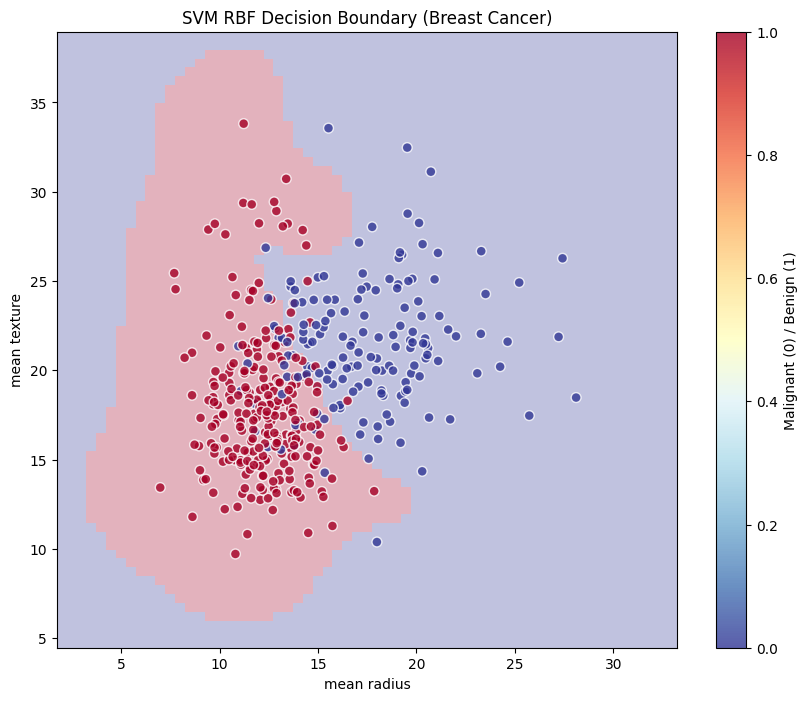

In [24]:
#Support vector machine - binomial
from sklearn.svm import SVC
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer=load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer['data'], cancer['target'], random_state=0)
sv_l=SVC(kernel='linear').fit(X_train, y_train)
print("Training accuracy of Linear kernel: ", sv_l.score(X_train, y_train))
print("Test accuracy of Linear kernel: ", sv_l.score(X_test, y_test))
print("----------------------------")
sv_r=SVC(kernel="rbf",gamma='scale').fit(X_train, y_train)
print("Training accuracy of RBF kernel: ", sv_r.score(X_train, y_train))
print("Test accuracy of RBF kernel: ", sv_r.score(X_test, y_test))

#-----------------------------------
import matplotlib.pyplot as plt
import numpy as np

# Raw features 0 & 1 (no scaling needed for demo)
feat1, feat2 = 0, 1
X_train_2d = X_train[:, [feat1, feat2]]

svm_rbf_2d = SVC(kernel='rbf', C=10, gamma=0.1).fit(X_train_2d, y_train)

# Meshgrid for decision boundary
x_min, x_max = X_train_2d[:, 0].min() - 5, X_train_2d[:, 0].max() + 5
y_min, y_max = X_train_2d[:, 1].min() - 5, X_train_2d[:, 1].max() + 5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.5), np.arange(y_min, y_max, 0.5))
Z = svm_rbf_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.pcolormesh(xx, yy, Z, cmap='RdYlBu_r', alpha=0.3)
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap='RdYlBu_r', 
            alpha=0.8, s=50, edgecolors='w')
plt.xlabel(cancer.feature_names[feat1])
plt.ylabel(cancer.feature_names[feat2])
plt.title('SVM RBF Decision Boundary (Breast Cancer)')
plt.colorbar(label='Malignant (0) / Benign (1)')
plt.show()

Training accuracy:  0.9910714285714286
Test accuracy:  0.9473684210526315
Data shape:  (150, 4)
Feature names:  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Test class:  ['setosa' 'versicolor' 'virginica']
Test predictions:  [1 1 0 1 1 1 1 1 0 2 0 0 2 2 0 1 0 1 2 0 0 0 1 2 0 0 0 0 0 1 2 1 2 0 2 1 0
 1]


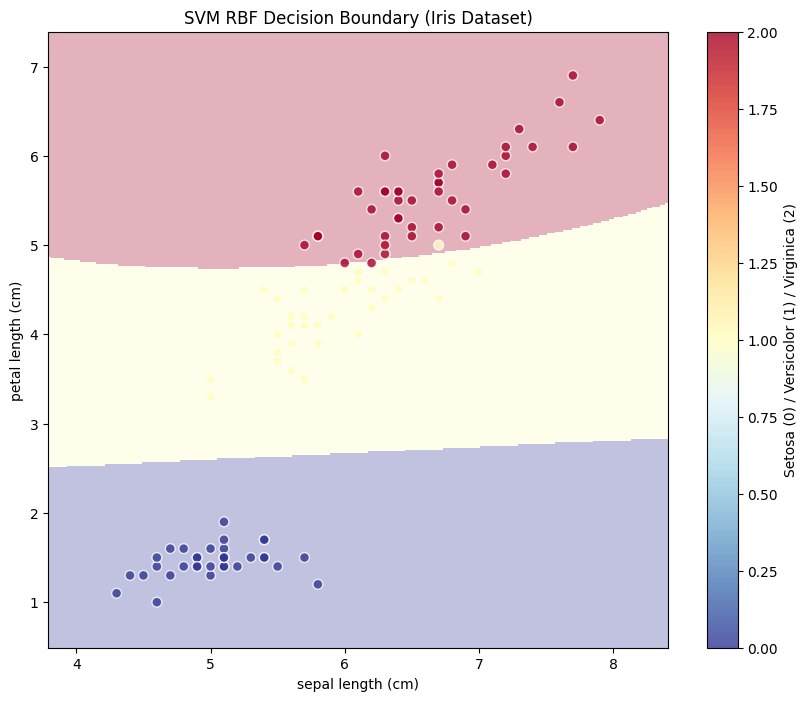

In [3]:
#Support vector machine - multinomial
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

iris=load_iris()
X_train, X_test, y_train, y_test=train_test_split(iris['data'], iris['target'])
sv_m=SVC(kernel='rbf').fit(X_train, y_train)
print("Training accuracy: ", sv_m.score(X_train, y_train))
print("Test accuracy: ", sv_m.score(X_test, y_test))
print("Data shape: ", iris.data.shape)
print("Feature names: ",iris.feature_names)
print("Test class: ", iris.target_names)
print("Test predictions: ", sv_m.predict(X_test))
#---------------
import matplotlib.pyplot as plt
import numpy as np
feat1, feat2 = 0,2
X_train_2d = X_train[:, [feat1, feat2]]

sv_2d = SVC(kernel='rbf', C=10, gamma=0.1).fit(X_train_2d, y_train)

# Create meshgrid for hyperplane
x_min, x_max = X_train_2d[:, 0].min() - 0.5, X_train_2d[:, 0].max() + 0.5
y_min, y_max = X_train_2d[:, 1].min() - 0.5, X_train_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), 
                     np.arange(y_min, y_max, 0.02))
Z = sv_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Plot
'''plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu_r', levels=[-1, 0.5, 2])
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, 
           cmap='RdYlBu_r', alpha=0.8, s=60, edgecolors='w', linewidth=0.5)

# Plot decision boundary line
if hasattr(sv_2d, 'coef_'):
    ax = plt.gca()
    coef = sv_2d.coef_[0]
    intercept = sv_2d.intercept_[0]
    xx_line = np.linspace(x_min, x_max)
    yy_line = -(coef[0] * xx_line + intercept) / coef[1]
    plt.plot(xx_line, yy_line, 'k--', linewidth=2, label='Hyperplane')

plt.xlabel(iris.feature_names[feat1])
plt.ylabel(iris.feature_names[feat2])
plt.title('SVM Linear: Iris Classes with Hyperplane')
plt.legend()
plt.colorbar(label='Class Prediction')
plt.tight_layout()
plt.show()'''

plt.figure(figsize=(10, 8))
plt.pcolormesh(xx, yy, Z, cmap='RdYlBu_r', alpha=0.3)
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap='RdYlBu_r', 
            alpha=0.8, s=50, edgecolors='w')
plt.xlabel(iris.feature_names[feat1])
plt.ylabel(iris.feature_names[feat2])
plt.title('SVM RBF Decision Boundary (Iris Dataset)')
plt.colorbar(label='Setosa (0) / Versicolor (1) / Virginica (2)')
plt.show()

### Naive bayes classifier

Training accuracy:  0.9642857142857143
Test accuracy:  0.8947368421052632


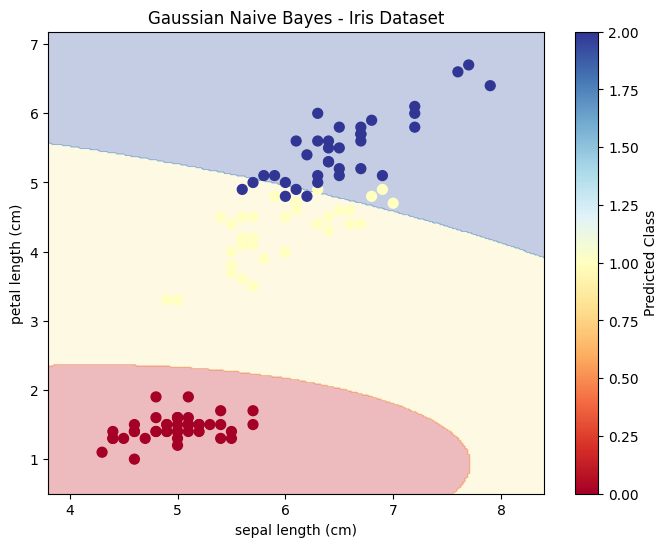

In [38]:
#Gaussian NB -- Iris:continous feature
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
iris=load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris['data'], iris['target'])
gnb=GaussianNB().fit(X_train, y_train)
print("Training accuracy: ", gnb.score(X_train, y_train))
print("Test accuracy: ", gnb.score(X_test,y_test))
#------------------
import matplotlib.pyplot as plt
import numpy as np
# 2D plot (features 0 & 2)
feat1, feat2 = 0, 2
X_train_2d = X_train[:, [feat1, feat2]]
gnb = GaussianNB().fit(X_train_2d, y_train)

x_min, x_max = X_train_2d[:, 0].min() - 0.5, X_train_2d[:, 0].max() + 0.5
y_min, y_max = X_train_2d[:, 1].min() - 0.5, X_train_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
Z = gnb.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap='RdYlBu', s=50)
plt.xlabel(iris.feature_names[feat1])
plt.ylabel(iris.feature_names[feat2])
plt.title('Gaussian Naive Bayes - Iris Dataset')
plt.colorbar(label='Predicted Class')
plt.show()


Feature names:  ['00' '000' '0000' ... 'íålittin' 'ñaustin' 'ýé']
Target names:  ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']
Target val:  [17  7 10 ... 14 12 11]
Training accuracy:  0.8130819092516205
Test accuracy:  0.719688936019795
Test prediction:  [14  5 15 ... 10 18 10]


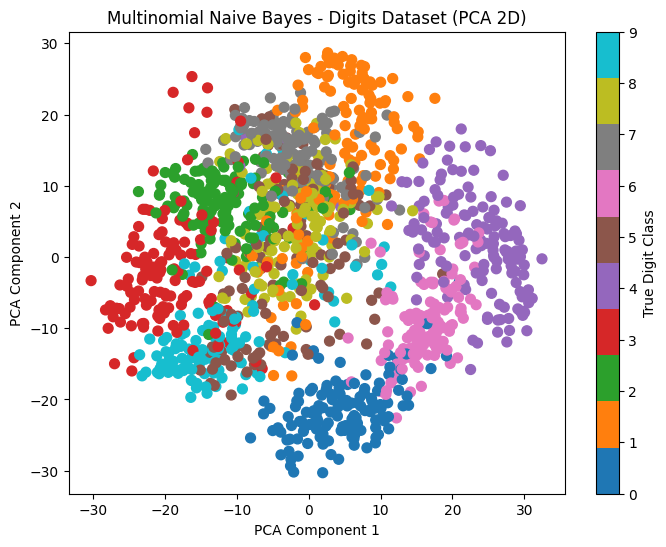

In [39]:
#Multinomial NB -- 20newsgroup: text count
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_20newsgroups_vectorized

text=fetch_20newsgroups_vectorized()
X_train, X_test, y_train, y_test = train_test_split(text['data'], text['target'], random_state=0)
mnb=MultinomialNB().fit(X_train, y_train)
print("Feature names: ", text.feature_names)
print("Target names: ", text.target_names)
print("Target val: ", text.target)
print("Training accuracy: ", mnb.score(X_train, y_train))
print("Test accuracy: ", mnb.score(X_test, y_test))
print("Test prediction: ", mnb.predict(X_test))
#-----------------
digits = load_digits()
X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, random_state=0)

# Use first 2 principal components for visualization (digits are 64D)
from sklearn.decomposition import PCA
pca = PCA(n_components=2).fit(X_train)
X_train_pca = pca.transform(X_train)

mnb = MultinomialNB().fit(X_train, y_train)  # Train on full features
Z = mnb.predict(pca.inverse_transform(X_train_pca)).reshape(-1, 1)  # Back-project

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='tab10', s=50)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Multinomial Naive Bayes - Digits Dataset (PCA 2D)')
plt.colorbar(scatter, label='True Digit Class')
plt.show()


Feature names:  ['pixel_0_0', 'pixel_0_1', 'pixel_0_2', 'pixel_0_3', 'pixel_0_4', 'pixel_0_5', 'pixel_0_6', 'pixel_0_7', 'pixel_1_0', 'pixel_1_1', 'pixel_1_2', 'pixel_1_3', 'pixel_1_4', 'pixel_1_5', 'pixel_1_6', 'pixel_1_7', 'pixel_2_0', 'pixel_2_1', 'pixel_2_2', 'pixel_2_3', 'pixel_2_4', 'pixel_2_5', 'pixel_2_6', 'pixel_2_7', 'pixel_3_0', 'pixel_3_1', 'pixel_3_2', 'pixel_3_3', 'pixel_3_4', 'pixel_3_5', 'pixel_3_6', 'pixel_3_7', 'pixel_4_0', 'pixel_4_1', 'pixel_4_2', 'pixel_4_3', 'pixel_4_4', 'pixel_4_5', 'pixel_4_6', 'pixel_4_7', 'pixel_5_0', 'pixel_5_1', 'pixel_5_2', 'pixel_5_3', 'pixel_5_4', 'pixel_5_5', 'pixel_5_6', 'pixel_5_7', 'pixel_6_0', 'pixel_6_1', 'pixel_6_2', 'pixel_6_3', 'pixel_6_4', 'pixel_6_5', 'pixel_6_6', 'pixel_6_7', 'pixel_7_0', 'pixel_7_1', 'pixel_7_2', 'pixel_7_3', 'pixel_7_4', 'pixel_7_5', 'pixel_7_6', 'pixel_7_7']
Target names:  [0 1 2 3 4 5 6 7 8 9]
Target val:  [0 1 2 ... 8 9 8]
Training accuracy:  0.8671121009651076
Test accuracy:  0.8511111111111112
Test pred

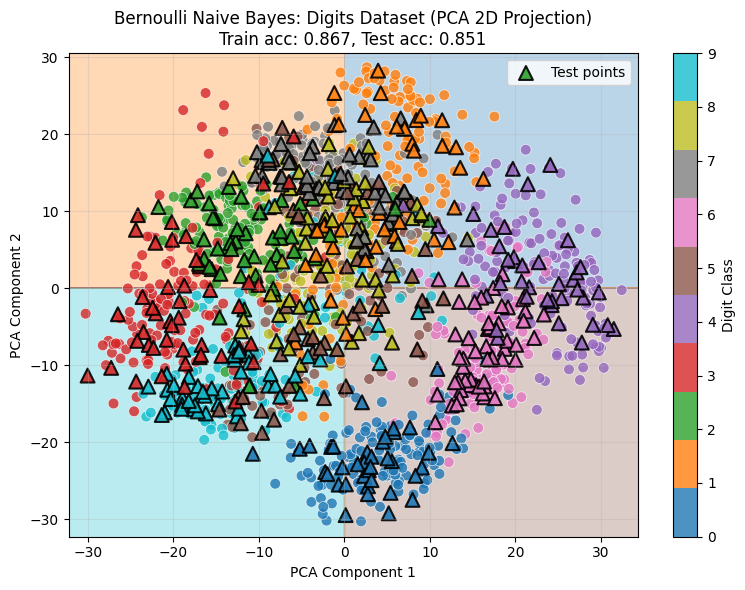

In [41]:
#BernoulliNB -- Binary digits:binarized images
from sklearn.naive_bayes import BernoulliNB
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

digit=load_digits()
X_train, X_test, y_train, y_test = train_test_split(digit['data'], digit['target'], random_state=0)
bnb=BernoulliNB().fit(X_train, y_train)
print("Feature names: ", digit.feature_names)
print("Target names: ", digit.target_names)
print("Target val: ", digit.target)
print("Training accuracy: ", bnb.score(X_train, y_train))
print("Test accuracy: ", bnb.score(X_test, y_test))
print("Test prediction: ", bnb.predict(X_test))
#--------------
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# Use your exact setup
digit = load_digits()
X_train, X_test, y_train, y_test = train_test_split(digit.data, digit.target, random_state=0)
bnb = BernoulliNB().fit(X_train, y_train)

# Reduce 64D to 2D for visualization using PCA
pca = PCA(n_components=2).fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

# Retrain on PCA 2D projection for decision boundary
bnb_2d = BernoulliNB().fit(X_train_pca, y_train)

# Create meshgrid for decision regions
x_min, x_max = X_train_pca[:, 0].min() - 2, X_train_pca[:, 0].max() + 2
y_min, y_max = X_train_pca[:, 1].min() - 2, X_train_pca[:, 1].max() + 2
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.2), np.arange(y_min, y_max, 0.2))
Z = bnb_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Plot
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='tab10', levels=10)
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, 
                     cmap='tab10', alpha=0.8, s=60, edgecolors='w', linewidth=0.5)

# Test points overlay
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, 
           cmap='tab10', marker='^', s=100, edgecolors='black', 
           linewidth=1.5, alpha=0.9, label='Test points')

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Bernoulli Naive Bayes: Digits Dataset (PCA 2D Projection)\nTrain acc: {:.3f}, Test acc: {:.3f}'.format(
    bnb.score(X_train, y_train), bnb.score(X_test, y_test)))
plt.colorbar(scatter, label='Digit Class')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Decision Tree

Before Pre-pruning
Training accuracy:  1.0
Test accuracy:  0.8811188811188811
Feature importance:  [0.         0.0096886  0.         0.         0.         0.
 0.         0.71160121 0.         0.         0.01948008 0.
 0.         0.01676117 0.017502   0.         0.         0.
 0.         0.         0.         0.06706044 0.         0.11373562
 0.         0.03421113 0.00995974 0.         0.         0.        ]
----------------------------------
After Pre-pruning
Training Accuracy:  0.9929577464788732
Test Accuracy:  0.9020979020979021
Feature Importance:  [0.         0.         0.         0.         0.         0.
 0.         0.72099985 0.         0.         0.         0.
 0.02007711 0.01727487 0.         0.         0.         0.
 0.0124106  0.         0.         0.05097828 0.         0.11722141
 0.         0.03525964 0.01026499 0.         0.         0.01551325]


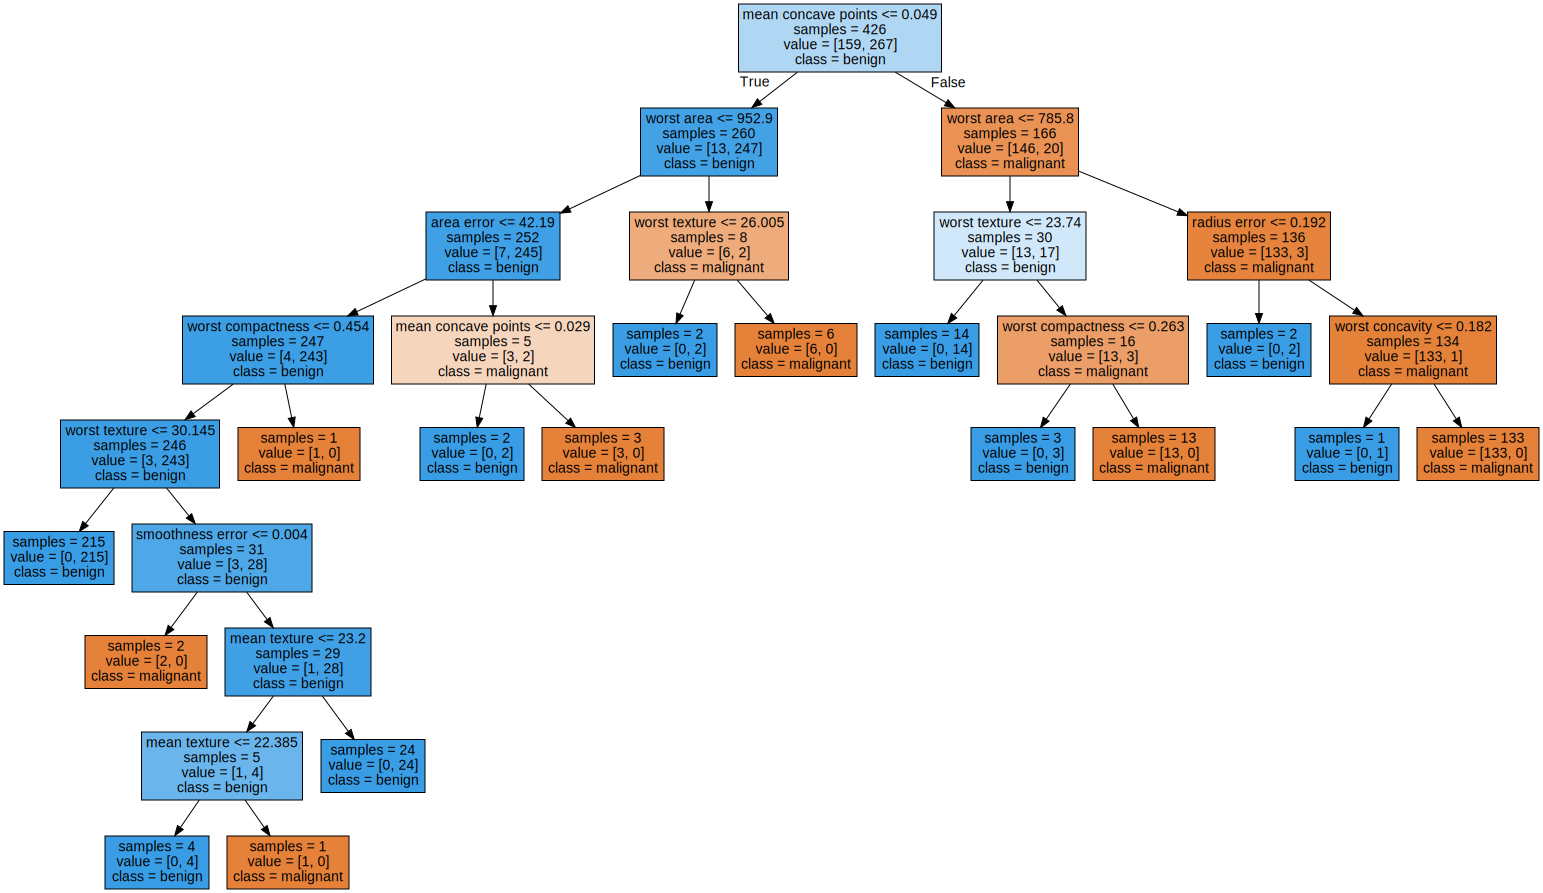

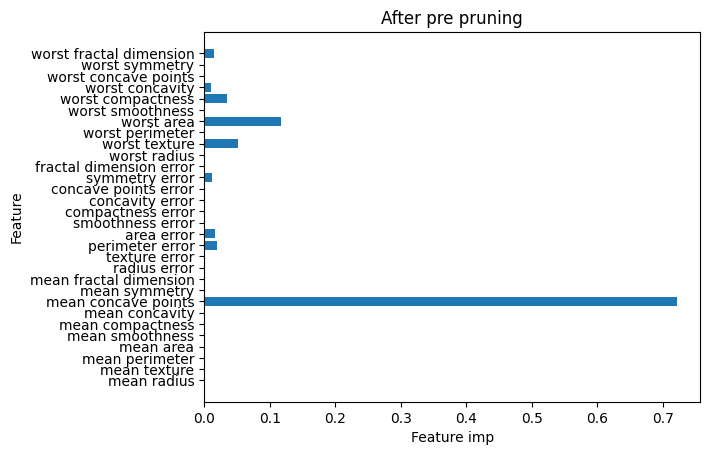

In [20]:
#Decision tree classifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

cancer=load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer['data'], cancer['target'], random_state=0)
print("Before Pre-pruning")
tree=DecisionTreeClassifier(random_state=0).fit(X_train, y_train)
print("Training accuracy: ", tree.score(X_train, y_train))
print("Test accuracy: ", tree.score(X_test, y_test))
print("Feature importance: ",tree.feature_importances_)
# def plot_feature(model):
#     n_features=cancer.data.shape[1]
#     plt.barh(range(n_features), model.feature_importances_, align='center')
#     plt.yticks(np.arange(n_features), cancer.feature_names)
#     plt.xlabel("Feature imp")
#     plt.ylabel("Feature")
#     plt.title("Before pre pruning")
# plot_feature(tree)

print("----------------------------------")

print("After Pre-pruning")
tree_p=DecisionTreeClassifier(max_depth=4, random_state=0).fit(X_train, y_train)
print("Training Accuracy: ", tree_p.score(X_train, y_train))
print("Test Accuracy: ", tree_p.score(X_test, y_test))
print("Feature Importance: ", tree_p.feature_importances_)
def plot_feature_pruning(model):
    n_features=cancer.data.shape[1]
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), cancer.feature_names)
    plt.xlabel("Feature imp")
    plt.ylabel("Feature")
    plt.title("After pre pruning")
plot_feature_pruning(tree_p)

#Graph
from sklearn.tree import export_graphviz
import graphviz
export_graphviz(tree, out_file='tree.dot', class_names=['malignant', 'benign'], feature_names=cancer.feature_names, impurity=False, filled=True)
with open('tree.dot') as f:
    dot_graph=f.read()
graphviz.Source(dot_graph)


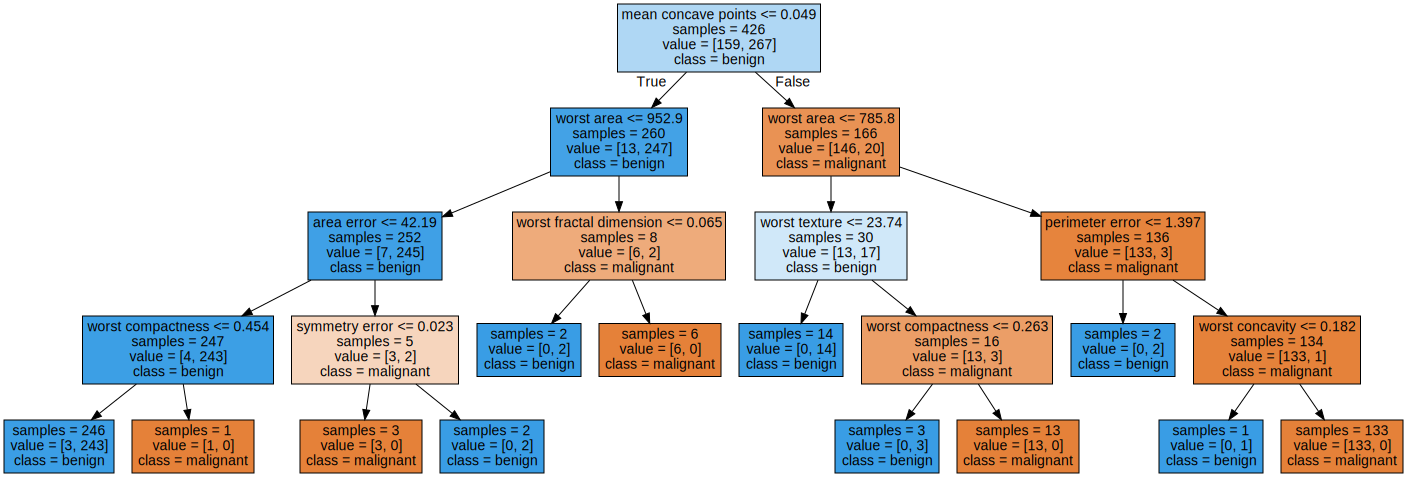

In [14]:

export_graphviz(tree_p, out_file='tree_p.dot', class_names=['malignant', 'benign'], feature_names=cancer.feature_names, impurity=False, filled=True)
with open('tree_p.dot') as f:
    dot_graph_p=f.read()
graphviz.Source(dot_graph_p)

In [5]:
#Decision tree regressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt

diab=fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(diab['data'], diab['target'], random_state=0)
tree_reg=DecisionTreeRegressor(max_depth=4, random_state=0).fit(X_train, y_train)
print("Training accuracy: ", tree_reg.score(X_train, y_train))
print("Test accuracy: ", tree_reg.score(X_test, y_test))

Training accuracy:  0.5923317530961604
Test accuracy:  0.5535230443888923


### Random Forest

Training accuracy:  0.9977728285077951
Test accuracy:  0.8911111111111111
Feature importances:
  [0.         0.00718211 0.01859572 0.01108524 0.01353945 0.01797641
 0.01758433 0.00030024 0.         0.00366674 0.02328725 0.00220135
 0.00708346 0.01270841 0.00639516 0.00098096 0.         0.00471402
 0.01808793 0.05173771 0.03110289 0.07087816 0.00263691 0.
 0.         0.00986721 0.02232028 0.02936939 0.01593369 0.02127812
 0.01198502 0.         0.         0.03441507 0.0379247  0.02926046
 0.04756244 0.02896419 0.01353494 0.         0.         0.01566708
 0.02208382 0.04232226 0.02935617 0.02627417 0.02772467 0.
 0.         0.00283754 0.02146027 0.03251251 0.00718624 0.02240796
 0.00997439 0.00031102 0.         0.00079687 0.0297213  0.01275646
 0.02199993 0.04366258 0.00555276 0.00123204]


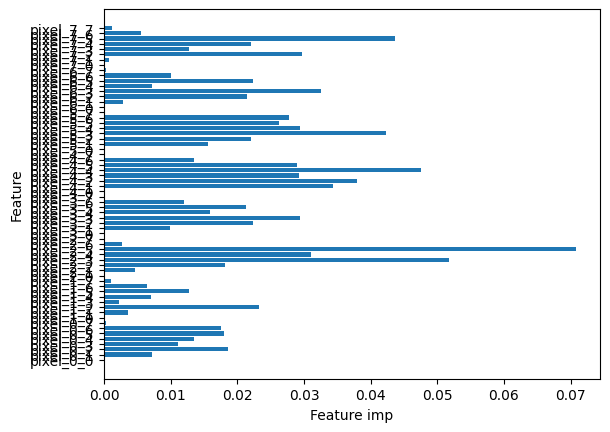

In [12]:
#Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

digi=load_digits()
X_train, X_test, y_train, y_test = train_test_split(digi['data'], digi['target'], random_state=0)
tree_c=RandomForestClassifier(n_estimators=5, random_state=0).fit(X_train, y_train)
print("Training accuracy: ", tree_c.score(X_train, y_train))
print("Test accuracy: ", tree_c.score(X_test, y_test))

#Feature importance
print("Feature importances:\n ", tree_c.feature_importances_)
def plot_feature_pruning(model):
    n_features=digi.data.shape[1]
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), digi.feature_names)
    plt.xlabel("Feature imp")
    plt.ylabel("Feature")
    # plt.title("After pre pruning")
plot_feature_pruning(tree_c)

Training accuracy:  0.9651099881918717
Test accuracy:  0.7828332803331154
Feature Importance:
  [0.52856659 0.05621693 0.0485046  0.02914347 0.0314317  0.13616165
 0.08382616 0.08614889]


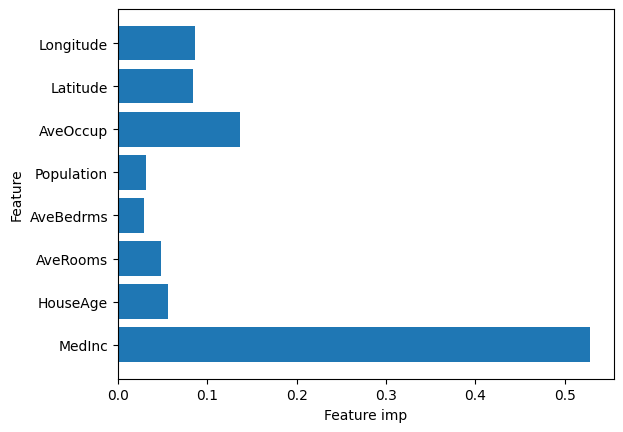

In [15]:
#Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing

diab=fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(diab['data'], diab['target'], random_state=0)
tree_reg=RandomForestRegressor(n_estimators=15, random_state=2).fit(X_train, y_train)
print("Training accuracy: ", tree_reg.score(X_train, y_train))
print("Test accuracy: ", tree_reg.score(X_test, y_test))
print("Feature Importance:\n ", tree_reg.feature_importances_)
def plot_feature_pruning(model):
    n_features=diab.data.shape[1]
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), diab.feature_names)
    plt.xlabel("Feature imp")
    plt.ylabel("Feature")
    # plt.title("After pre pruning")
plot_feature_pruning(tree_reg)

### Gradient Boosting Machines

In [16]:
#Gradient boosting classifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris=load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris['data'], iris['target'], random_state=0)
gbc=GradientBoostingClassifier(max_depth=5,random_state=0, learning_rate=0.1).fit(X_train, y_train)

print("Training accuracy: ", gbc.score(X_train, y_train))
print("Test accuracy: ", gbc.score(X_test, y_test))


Training accuracy:  1.0
Test accuracy:  0.9736842105263158


In [9]:
#Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

house=fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(house['data'], house['target'], random_state=0)
gbr=GradientBoostingRegressor(n_estimators=500, random_state=0).fit(X_train, y_train)

print("Training accuracy: ", gbr.score(X_train, y_train))
print("Test accuracy: ", gbr.score(X_test, y_test))

Training accuracy:  0.8719838166264939
Test accuracy:  0.8243928247263258


### XGBoost

In [3]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [8]:
#XGBClassifier
from xgboost import XGBClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris=load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris['data'], iris['target'], random_state=0)
xgbc=XGBClassifier(n_estimators=50, learning_rate=0.01, random_state=0).fit(X_train, y_train)
print("Training accuracy: ", xgbc.score(X_train, y_train))
print("Test accuracy: ", xgbc.score(X_test, y_test))

Training accuracy:  0.9821428571428571
Test accuracy:  0.9736842105263158


In [29]:
#XGRegressor
from xgboost import XGBRegressor
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
diab=load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(diab['data'], diab['target'], random_state=42)
xgbr=XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=3, reg_alpha=1, random_state=42).fit(X_train, y_train)
print("Training accuracy: ", xgbr.score(X_train, y_train))
print("Test accuracy: ", xgbr. score(X_test, y_test))

Training accuracy:  0.9365002215883064
Test accuracy:  0.41721026063495337


### Multi Layer Perceptron

Training accuracy:  1.0
Test accuracy:  0.9777777777777777
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       0.94      0.98      0.96        46
           2       0.98      0.98      0.98        44
           3       0.96      0.96      0.96        46
           4       1.00      0.98      0.99        45
           5       0.98      1.00      0.99        46
           6       1.00      0.98      0.99        45
           7       1.00      1.00      1.00        45
           8       0.93      0.98      0.95        43
           9       1.00      0.93      0.97        45

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450



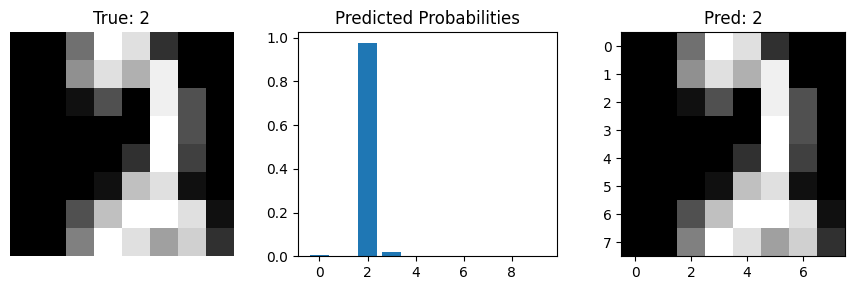

In [9]:
#MLPClassifier
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

digit=load_digits()
X_train, X_test, y_train, y_test = train_test_split(digit['data'], digit['target'], random_state=0, stratify=digit['target']) #stratify=y ensures the train/test split maintains the same class proportions as the original dataset.

#Scale features (Critical for MLP GD)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

#Model
mlpc=MLPClassifier(hidden_layer_sizes=(100,50), activation='relu', solver='adam', alpha=0.01, batch_size='auto', learning_rate='constant', max_iter=400, random_state=0)
mlpc.fit(X_train_scaled, y_train)

y_test_pred=mlpc.predict(X_test_scaled)
print("Training accuracy: ", mlpc.score(X_train_scaled, y_train))
print("Test accuracy: ", mlpc.score(X_test_scaled, y_test))
print("Classification report:\n", classification_report(y_test, y_test_pred))

# Visualize first test image prediction
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(X_test[0].reshape(8, 8), cmap='gray')
axes[0].set_title(f'True: {y_test[0]}')
axes[0].axis('off')
axes[1].bar(range(10), mlpc.predict_proba(X_test_scaled)[0])
axes[1].set_title('Predicted Probabilities')
axes[2].imshow(X_test[0].reshape(8, 8), cmap='gray')
axes[2].set_title(f'Pred: {y_test_pred[0]}')
plt.tight_layout()
plt.show()

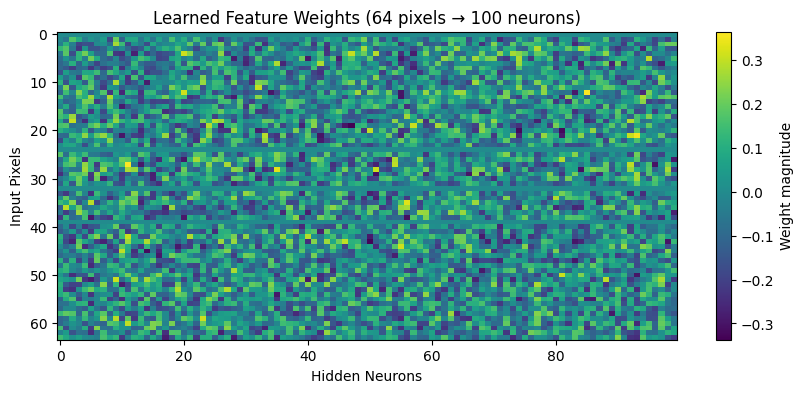

RFC Accuracy: 0.978


In [12]:
# Feature importance (weights visualization)
plt.figure(figsize=(10,4))
plt.imshow(mlpc.coefs_[0], aspect='auto', cmap='viridis')  # Input→Hidden1 weights
plt.colorbar(label='Weight magnitude')
plt.title('Learned Feature Weights (64 pixels → 100 neurons)')
plt.xlabel('Hidden Neurons')
plt.ylabel('Input Pixels')
plt.show()

# Compare with RandomForest (your previous models)
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(X_train_scaled, y_train)
print(f"RFC Accuracy: {rf.score(X_test_scaled, y_test):.3f}")  # ~0.98, similar


In [33]:
#MLPRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

diab=load_diabetes()
print(diab.keys())
print("Diabetes Features: ", diab.feature_names)
print("Diabetes Target: ", diab.target_filename)
X_train, X_test, y_train, y_test = train_test_split(diab['data'], diab['target'], random_state=0)

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

mlpr=MLPRegressor(hidden_layer_sizes=(50, 25), max_iter=2000, random_state=0, alpha=0.1, early_stopping=True, validation_fraction=0.2)
mlpr.fit(X_train_scaled, y_train)
y_pred_test = mlpr.predict(X_test_scaled)

print("Training accuracy: ", mlpr.score(X_train_scaled, y_train))
print("Test accuracy: ", mlpr.score(X_test_scaled, y_test))
print("RMSE Score: ", np.sqrt(mean_squared_error(y_test, y_pred_test)))

#Comparison with RandomForestregressor
from sklearn.ensemble import RandomForestRegressor
rfr=RandomForestRegressor(n_estimators=100, random_state=0, max_depth=3).fit(X_train_scaled, y_train)
y_pred_test_rfr=rfr.predict(X_test_scaled)
print("RFR training accuracy: ", rfr.score(X_train_scaled, y_train))
print("RFR test accuracy: ", rfr.score(X_test_scaled, y_test))
print("RFR RMSE Score: ", np.sqrt(mean_squared_error(y_test, y_pred_test_rfr)))

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])
Diabetes Features:  ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Diabetes Target:  diabetes_target.csv.gz
Training accuracy:  0.5852361547275235
Test accuracy:  0.26418567942030624
RMSE Score:  60.43911500191719
RFR training accuracy:  0.6251894825489268
RFR test accuracy:  0.27085805231856563
RFR RMSE Score:  60.16445963719737


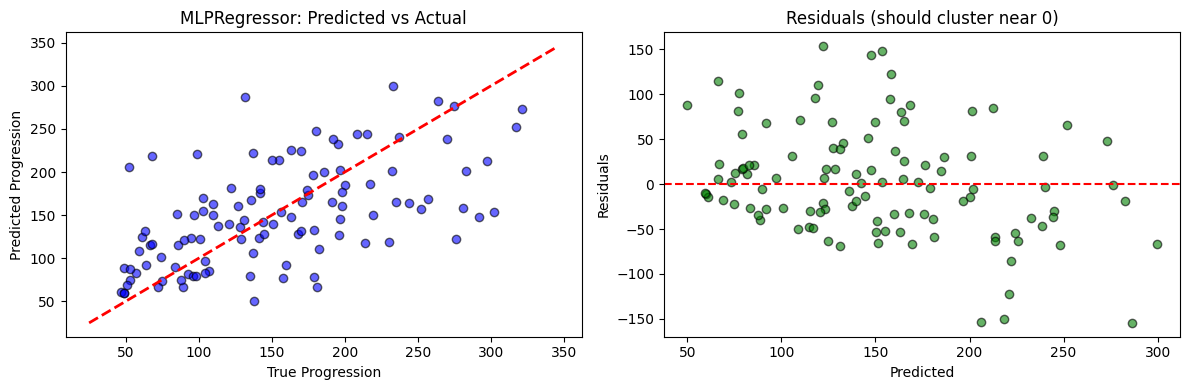

In [27]:
y=diab['target']
# Plot predictions vs true
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Scatter: predicted vs actual
ax1.scatter(y_test, y_pred_test, alpha=0.6, c='blue', edgecolors='k')
ax1.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
ax1.set_xlabel('True Progression')
ax1.set_ylabel('Predicted Progression')
ax1.set_title('MLPRegressor: Predicted vs Actual')

# Residuals plot
residuals = y_test - y_pred_test
ax2.scatter(y_pred_test, residuals, alpha=0.6, c='green', edgecolors='k')
ax2.axhline(y=0, color='r', linestyle='--')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Residuals')
ax2.set_title('Residuals (should cluster near 0)')

plt.tight_layout()
plt.show()

### Uncertainity Estimates from classifiers using decision_function and predict_proba

In [11]:
#Binary Decision function
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer=load_breast_cancer()
X_train, X_test, y_train,y_test = train_test_split(cancer['data'], cancer['target'], random_state=0)
gbc=GradientBoostingClassifier(random_state=0).fit(X_train, y_train)

#Decision function
print("Test accuracy: ", gbc.score(X_test, y_test))
print("X_test.shape: ", X_test.shape)
print("Decision function shape: ", gbc.decision_function(X_test).shape) # Return shape
print("Decision Function:\n ", gbc.decision_function(X_test)) #Provides values in that shape
print("Thresholded decision function: ", gbc.decision_function(X_test)>0)
print("Predictions: ", gbc.predict(X_test))
df = pd.DataFrame({
"DF": gbc.decision_function(X_test),
"TDF": gbc.decision_function(X_test) > 0,
"Pred": gbc.predict(X_test)
})
df

Test accuracy:  0.965034965034965
X_test.shape:  (143, 30)
Decision function shape:  (143,)
Decision Function:
  [-6.71498791  5.73184677  7.3579928   4.96244648  7.7051529   8.00066721
  6.48400234  7.43027078  6.79218125  8.25760176 -1.00039531  4.46768772
  7.72380755 -1.3736094  -0.94901587 -5.44780967  4.05938405 -7.17393192
 -7.42955073 -7.5184186  -7.07050307 -5.36145017  7.53827759  8.1132933
 -6.5130852   8.38593648  7.71944649 -5.11758962  7.6742251  -7.77300711
  7.76771705 -7.12545037  6.17451365 -7.40121845  7.66616299 -8.05830657
  7.22229492 -6.13984742  6.53827911 -7.68413924  0.39901562  7.20833685
 -1.18927645  7.66616299  2.79836777 -7.68413924  7.66616299  6.63910994
  7.43027078 -7.73117291 -6.50904228 -3.96351589 -7.7829456   8.06108841
  8.24928765  7.40922844  5.73563845  4.86740878  5.46947476 -7.40393283
 -7.57863519 -7.3126909   8.25760176  8.1132933  -5.98948856  2.34511198
 -7.65078202 -7.42955073 -7.42955073  6.91268901  2.58589965 -7.81047955
  8.00066721

,DF,TDF,Pred
0,-6.714988,False,0
1,5.731847,True,1
2,7.357993,True,1
3,4.962446,True,1
4,7.705153,True,1
...,...,...,...
138,-7.773007,False,0
139,8.249288,True,1
140,7.819922,True,1
141,6.939108,True,1


In [12]:
# Map TDF (True/False) to 1/0 and compare with Pred
df['TDF_numeric'] = df['TDF'].astype(int)  # True=1, False=0
df['Match'] = df['TDF_numeric'] == df['Pred']

# Count matches and mismatches
matches = df['Match'].sum()
mismatches = len(df) - matches

print(f"Matches: {matches}")
print(f"Mismatches: {mismatches}")
print(f"Accuracy: {matches/len(df)*100:.1f}%")


Matches: 143
Mismatches: 0
Accuracy: 100.0%


In [15]:
#Multiclass Decision Function
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris=load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris['data'], iris['target'], random_state=42)
gbc_m=GradientBoostingClassifier().fit(X_train, y_train)
print("Test accuracy: ", gbc_m.score(X_test, y_test))
print("Test data shape: ", X_test.shape)
print("Decision function shape: ", gbc_m.decision_function(X_test).shape)
print("Decision Function: ", gbc_m.decision_function(X_test))
print("Argmax of decision function: ", np.argmax(gbc_m.decision_function(X_test), axis=1))
print("Predictions: ", gbc_m.predict(X_test))

Test accuracy:  1.0
Test data shape:  (38, 4)
Decision function shape:  (38, 3)
Decision Function:  [[-6.97579793  2.7731495  -4.75421757]
 [ 7.33907675 -1.67857649 -5.37584532]
 [-6.95427555 -4.89666235  5.08699272]
 [-6.97579793  3.29727516 -4.16277348]
 [-7.00127248  3.55530861 -4.12188298]
 [ 7.33830717 -2.11593521 -5.37584532]
 [-6.97580174  2.88753401 -5.38276721]
 [-6.96391632 -1.55501021  5.12200564]
 [-6.97577875  2.37404594 -3.60087244]
 [-6.97578256  3.74503685 -5.38232673]
 [-6.96400533 -1.21300383  5.06570741]
 [ 7.33830717 -2.46798521 -5.37584532]
 [ 7.33908013 -1.76543657 -5.37584532]
 [ 7.33830717 -2.46798521 -5.37584532]
 [ 7.33830717 -2.31879179 -5.37584532]
 [-6.99648155  3.92574227 -4.90388379]
 [-6.95428211 -4.65802661  5.94890105]
 [-6.97578256  3.65817678 -5.42378677]
 [-6.97580174  2.45026843 -5.38276721]
 [-6.95435507 -5.18215227  5.94890105]
 [ 7.33830717 -2.46798521 -5.37584532]
 [-7.00991287 -1.31711882  5.13631695]
 [ 7.33830717 -2.31879179 -5.37584532]
 [-

In [21]:
#Binary Predicting Probabilities
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer=load_breast_cancer()
X_train, X_test, y_train,y_test = train_test_split(cancer['data'], cancer['target'], random_state=0)
gbc=GradientBoostingClassifier(random_state=0).fit(X_train, y_train)

print("Test accuracy: ", gbc.score(X_test, y_test))
print("Test data shape: ", X_test.shape)
print("Shape of probabilities: ", gbc.predict_proba(X_test).shape)
print("Predicted probabilities: ", gbc.predict_proba(X_test))

Test accuracy:  0.965034965034965
Test data shape:  (143, 30)
Shape of probabilities:  (143, 2)
Predicted probabilities:  [[9.98788868e-01 1.21113206e-03]
 [3.23061546e-03 9.96769385e-01]
 [6.37070603e-04 9.99362929e-01]
 [6.94719074e-03 9.93052809e-01]
 [4.50296952e-04 9.99549703e-01]
 [3.35126530e-04 9.99664873e-01]
 [1.52535385e-03 9.98474646e-01]
 [5.92675438e-04 9.99407325e-01]
 [1.12125897e-03 9.98878741e-01]
 [2.59212853e-04 9.99740787e-01]
 [7.31136294e-01 2.68863706e-01]
 [1.13436608e-02 9.88656339e-01]
 [4.41978364e-04 9.99558022e-01]
 [7.97962680e-01 2.02037320e-01]
 [7.20917218e-01 2.79082782e-01]
 [9.95712734e-01 4.28726556e-03]
 [1.69668058e-02 9.83033194e-01]
 [9.99234283e-01 7.65716985e-04]
 [9.99406898e-01 5.93102094e-04]
 [9.99457304e-01 5.42695893e-04]
 [9.99150916e-01 8.49083933e-04]
 [9.95327838e-01 4.67216237e-03]
 [5.32030487e-04 9.99467970e-01]
 [2.99441110e-04 9.99700559e-01]
 [9.98518304e-01 1.48169586e-03]
 [2.28000097e-04 9.99772000e-01]
 [4.43909208e-04 9.9

In [23]:
#Multiclass predicting probabilities
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris=load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris['data'], iris['target'], random_state=42)
gbc_m=GradientBoostingClassifier().fit(X_train, y_train)

print("Predicting probabilities shape: ", gbc_m.predict_proba(X_test).shape)
print("Predicting probabilities : ", gbc_m.predict_proba(X_test))
print("Argmax of predicted probabilities: ", np.argmax(gbc_m.predict_proba(X_test), axis=1))

Predicting probabilities shape:  (38, 3)
Predicting probabilities :  [[5.83212665e-05 9.99403846e-01 5.37832493e-04]
 [9.99875760e-01 1.21234907e-04 3.00555191e-06]
 [5.38797716e-06 4.21731268e-05 9.99952439e-01]
 [3.45299643e-05 9.99390193e-01 5.75277148e-04]
 [2.61837432e-05 9.99507544e-01 4.66272707e-04]
 [9.99918642e-01 7.83500666e-05 3.00800390e-06]
 [5.20324099e-05 9.99692038e-01 2.55929323e-04]
 [5.63106195e-06 1.26638761e-03 9.98727981e-01]
 [8.81675986e-05 9.97335439e-01 2.57639352e-03]
 [2.20775315e-05 9.99869285e-01 1.08637456e-04]
 [5.95302857e-06 1.87229326e-03 9.98121754e-01]
 [9.99941891e-01 5.51005704e-05 3.00807384e-06]
 [9.99885844e-01 1.11149956e-04 3.00558279e-06]
 [9.99941891e-01 5.51005704e-05 3.00807384e-06]
 [9.99933026e-01 6.39655477e-05 3.00804717e-06]
 [1.80495793e-05 9.99835642e-01 1.46308898e-04]
 [2.49004346e-06 2.47433228e-05 9.99972767e-01]
 [2.40807664e-05 9.99862237e-01 1.13682473e-04]
 [8.05568774e-05 9.99523212e-01 3.96231255e-04]
 [2.48988692e-06 1.